### Explo : sectorial and sub-sectorial indicators - all types of indicators 

In [3]:
import pandas as pd
from pathlib import Path

# Définition de votre seuil académique de départ
start_date = pd.to_datetime('2015-03-02')

# ── 1. Chargement de la base GLOBALE (indicators) ──
dir_global = Path("./indicators")
if dir_global.exists():
    files_global = list(dir_global.glob("*.parquet"))
    df_global = pd.concat([pd.read_parquet(f) for f in files_global], ignore_index=True)
    df_global = df_global.groupby('period').max().reset_index()
    df_global['period'] = pd.to_datetime(df_global['period'])
    
    # 🔥 FILTRAGE TEMPOREL STRICT ICI
    df_global = df_global[df_global['period'] >= start_date]
    
    df_global = df_global.sort_values('period')
    print(f"✓ Base GLOBALE chargée : {len(df_global)} jours, de {df_global['period'].min().date()} à {df_global['period'].max().date()}")
else:
    df_global = None
    print("⚠ Dossier ./indicators introuvable.")

# ── 2. Chargement de la base RÉGIONALE (indicators_geo) ──
dir_geo = Path("./indicators_geo") # Modifiez si votre dossier s'appelle autrement
if dir_geo.exists():
    files_geo = list(dir_geo.glob("*.parquet"))
    df_geo = pd.concat([pd.read_parquet(f) for f in files_geo], ignore_index=True)
    df_geo = df_geo.groupby(['period', 'region_key']).max().reset_index()
    df_geo['period'] = pd.to_datetime(df_geo['period'])
    
    # 🔥 FILTRAGE TEMPOREL STRICT ICI
    df_geo = df_geo[df_geo['period'] >= start_date]
    
    df_geo = df_geo.sort_values(['period', 'region_key'])
    print(f"✓ Base RÉGIONALE chargée : {len(df_geo)} lignes, avec les régions {list(df_geo['region_key'].unique())}")
    print(f"  Départ de la série : {df_geo['period'].min().date()}")
else:
    df_geo = None
    print("⚠ Dossier ./indicators_geo introuvable.")

✓ Base GLOBALE chargée : 4111 jours, de 2015-03-02 à 2026-06-19
✓ Base RÉGIONALE chargée : 53443 lignes, avec les régions ['Africa', 'China', 'European Union', 'France', 'India', 'Japan', 'Lebanon', 'Middle East', 'North America', 'Russia', 'South America', 'South East Asia', 'US']
  Départ de la série : 2015-03-02


In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_academic_subsectors_grid(df_geo, sector_name, regions, metric_prefix="att_weight", rolling_window=30, filename="Fig_Subsectors_Grid.pdf"):
    """
    Crée une planche académique lisible.
    - Camaïeu Bleu/Rouge
    - Vrais pourcentages (sans min-max scaling)
    - Espacements optimisés
    - Échelles Y indépendantes (sharey=False) pour ne pas écraser les courbes
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE "LATEX / NBER"
    # ==========================================
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,              
        "axes.titlesize": 10,        
        "axes.labelsize": 8,         
        "xtick.labelsize": 7,        
        "ytick.labelsize": 7,        
        "axes.linewidth": 0.6,       
        "xtick.major.width": 0.6,    
        "ytick.major.width": 0.6,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. IDENTIFICATION & PRÉPARATION
    # ==========================================
    prefix = f"{metric_prefix}_{sector_name}"
    cols_to_plot = [c for c in df_geo.columns if c == prefix or c.startswith(prefix + "_")]
    
    if not cols_to_plot:
        print(f"⚠ Aucun sous-secteur trouvé pour '{sector_name}'.")
        return
        
    df_plot = df_geo[df_geo['region_key'].isin(regions)][['period', 'region_key'] + cols_to_plot].copy()
    
    melted = df_plot.melt(
        id_vars=['period', 'region_key'], 
        value_vars=cols_to_plot, 
        var_name='Category', 
        value_name='Raw_Value'
    )
    
    def clean_name(c):
        if c == prefix: return f"{sector_name.upper()} (Total)"
        return c.replace(f"{prefix}_", "").replace("_", " ").title()
    
    melted['Category'] = melted['Category'].apply(clean_name)
    melted = melted.sort_values(by=['Category', 'region_key', 'period'])
    
    # Lissage 
    melted['Smoothed'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.rolling(window=rolling_window, min_periods=1).mean())
    )
    
    # Vrai pourcentage
    melted['Percentage'] = melted['Smoothed'] * 100
    
    # ==========================================
    # 3. TRACÉ DE LA GRILLE (relplot)
    # ==========================================
    academic_palette = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(regions))
    
    g = sns.relplot(
        data=melted, 
        kind="line",
        x="period", 
        y="Percentage",        
        col="Category", 
        hue="region_key",      
        style="region_key",    
        col_wrap=2,            
        height=4.0,            
        aspect=1.0,            
        # 🔥 MODIFICATION ICI : sharey=False permet à chaque graphique d'avoir sa propre échelle
        facet_kws={"sharey": False, "sharex": True, "despine": True},
        palette=academic_palette,
        linewidth=1.0,         
        alpha=0.85             
    )
    
    # ==========================================
    # 4. FINITIONS DES AXES 
    # ==========================================
    g.set_titles(col_template="{col_name}", fontweight="normal") 
    
    # On supprime le label Y global car l'échelle varie désormais d'un graphique à l'autre
    g.set_axis_labels("", "Attention Share (%)")
    
    def year_fmt(x, pos):
        year = mdates.num2date(x).year
        if year in [2015, 2020, 2025]:
            return str(year)
        return ""

    for ax in g.axes.flat:
        ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray', linewidth=0.5)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(FuncFormatter(year_fmt))
        ax.tick_params(labelbottom=True, length=3) 
        
        # S'assurer que chaque sous-graphique affiche bien ses graduations Y, 
        # même s'il n'est pas sur la colonne de gauche.
        ax.tick_params(labelleft=True)
        
        for label in ax.get_xticklabels():
            label.set_rotation(0)
            label.set_ha('center')
            
    # ==========================================
    # 5. GESTION DE LA LÉGENDE (Intégrée)
    # ==========================================
    if g._legend:
        g._legend.remove()
        
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    
    for line in handles:
        line.set_linewidth(0.5)
        line.set_alpha(1.0) 
        
    g.axes.flat[0].legend(
        handles, labels, 
        title="REGIONS", 
        loc="upper right",     
        frameon=True,          
        facecolor="white",     
        edgecolor="lightgray", 
        framealpha=0.95,
        fontsize=5,            
        title_fontsize=5,
        borderpad=0.5,
        labelspacing=0.4
    )
    
    # ==========================================
    # 6. TITRE ET EXPORT
    # ==========================================
    # Un peu plus d'espace wspace (horizontal) car les chiffres de l'axe Y s'affichent maintenant partout
    plt.subplots_adjust(top=0.92, hspace=0.35, wspace=0.25) 
    
    g.fig.suptitle(
        f"Topic Attention - {sector_name.title()}", 
        fontsize=12, 
        fontweight="normal",
        y=0.97
    )
    
    plt.savefig(filename)
    print(f"✔ Planche sauvegardée sous : {filename}")
    plt.show()

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

def plot_academic_subsectors_grid(df_geo, sector_name, regions, metric_prefix="att_weight", rolling_window=30, filename="Fig_Subsectors_Grid.pdf"):
    """
    Crée une planche académique lisible.
    - Camaïeu Bleu/Rouge
    - Vrais pourcentages (sans min-max scaling)
    - Espacements optimisés
    - Échelles Y indépendantes (sharey=False) pour ne pas écraser les courbes
    - 🔥 3 graphiques par ligne (col_wrap=3)
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE "LATEX / NBER"
    # ==========================================
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,              
        "axes.titlesize": 10,        
        "axes.labelsize": 8,         
        "xtick.labelsize": 7,        
        "ytick.labelsize": 7,        
        "axes.linewidth": 0.6,       
        "xtick.major.width": 0.6,    
        "ytick.major.width": 0.6,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. IDENTIFICATION & PRÉPARATION
    # ==========================================
    prefix = f"{metric_prefix}_{sector_name}"
    cols_to_plot = [c for c in df_geo.columns if c == prefix or c.startswith(prefix + "_")]
    
    if not cols_to_plot:
        print(f"⚠ Aucun sous-secteur trouvé pour '{sector_name}'.")
        return
        
    df_plot = df_geo[df_geo['region_key'].isin(regions)][['period', 'region_key'] + cols_to_plot].copy()
    
    melted = df_plot.melt(
        id_vars=['period', 'region_key'], 
        value_vars=cols_to_plot, 
        var_name='Category', 
        value_name='Raw_Value'
    )
    
    def clean_name(c):
        if c == prefix: return f"{sector_name.upper()} (Total)"
        return c.replace(f"{prefix}_", "").replace("_", " ").title()
    
    melted['Category'] = melted['Category'].apply(clean_name)
    melted = melted.sort_values(by=['Category', 'region_key', 'period'])
    
    # Lissage 
    melted['Smoothed'] = (
        melted.groupby(['Category', 'region_key'])['Raw_Value']
        .transform(lambda x: x.rolling(window=rolling_window, min_periods=1).mean())
    )
    
    # Vrai pourcentage
    melted['Percentage'] = melted['Smoothed'] * 100
    
    # ==========================================
    # 3. TRACÉ DE LA GRILLE (relplot)
    # ==========================================
    academic_palette = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(regions))
    
    g = sns.relplot(
        data=melted, 
        kind="line",
        x="period", 
        y="Percentage",        
        col="Category", 
        hue="region_key",      
        style="region_key",    
        col_wrap=3,            # 🔥 PASSAGE À 3 COLONNES
        height=3.5,            # 🔥 HAUTEUR AJUSTÉE pour garder un bon ratio global
        aspect=1.0,            
        facet_kws={"sharey": False, "sharex": True, "despine": True},
        palette=academic_palette,
        linewidth=1.0,         
        alpha=0.85             
    )
    
    # ==========================================
    # 4. FINITIONS DES AXES 
    # ==========================================
    g.set_titles(col_template="{col_name}", fontweight="normal") 
    
    # On supprime le label Y global car l'échelle varie désormais d'un graphique à l'autre
    g.set_axis_labels("", "Attention Share (%)")
    
    def year_fmt(x, pos):
        year = mdates.num2date(x).year
        if year in [2015, 2020, 2025]:
            return str(year)
        return ""

    for ax in g.axes.flat:
        ax.grid(True, axis='y', linestyle=':', alpha=0.5, color='gray', linewidth=0.5)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(FuncFormatter(year_fmt))
        ax.tick_params(labelbottom=True, length=3) 
        
        # S'assurer que chaque sous-graphique affiche bien ses graduations Y, 
        # même s'il n'est pas sur la colonne de gauche.
        ax.tick_params(labelleft=True)
        
        for label in ax.get_xticklabels():
            label.set_rotation(0)
            label.set_ha('center')
            
    # ==========================================
    # 5. GESTION DE LA LÉGENDE (Intégrée)
    # ==========================================
    if g._legend:
        g._legend.remove()
        
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    
    for line in handles:
        line.set_linewidth(0.5)
        line.set_alpha(1.0) 
        
    g.axes.flat[0].legend(
        handles, labels, 
        title="REGIONS", 
        loc="upper right",     
        frameon=True,          
        facecolor="white",     
        edgecolor="lightgray", 
        framealpha=0.95,
        fontsize=5,            
        title_fontsize=5,
        borderpad=0.5,
        labelspacing=0.4
    )
    
    # ==========================================
    # 6. TITRE ET EXPORT
    # ==========================================
    # 🔥 wspace=0.35 : élargi pour éviter que les chiffres de l'axe Y touchent les graphiques
    plt.subplots_adjust(top=0.92, hspace=0.25, wspace=0.25) 
    
    g.fig.suptitle(
        f"Topic Attention - {sector_name.title()}", 
        fontsize=12, 
        fontweight="normal",
        y=0.97
    )
    
    plt.savefig(filename)
    print(f"✔ Planche sauvegardée sous : {filename}")
    plt.show()

### Viz

plot_gdelt_indicator(df_global, df_geo, metric, mode="sectors", sector_name=None, sector_keys=None, region_keys=None, region_filter=None, rolling_window=14):
    
    """
    Trace la série temporelle d'un indicateur GDELT en piochant intelligemment dans la base globale ou régionale.

    Paramètres:
    - df_global : DataFrame des indicateurs mondiaux.
    - df_geo : DataFrame des indicateurs régionaux.
    - metric : str, l'indicateur à tracer (ex: 'att_weight', 'sent_cont', 'axs_bin').
    - mode : 'sectors', 'categories', ou 'regions'.
    - sector_name : str, requis si mode='categories' ou 'regions'.
    - sector_keys : list, requis si mode='sectors'.
    - region_keys : list, requis si mode='regions' (ex: ['US', 'France']).
    - region_filter : str, optionnel. Permet d'appliquer le mode 'sectors/categories' sur UN seul pays.
    - rolling_window : int, jours pour la moyenne mobile (1 = données brutes).
    """

✔ Planche sauvegardée sous : ./plots/attention_time_series/finance_subsectors.png


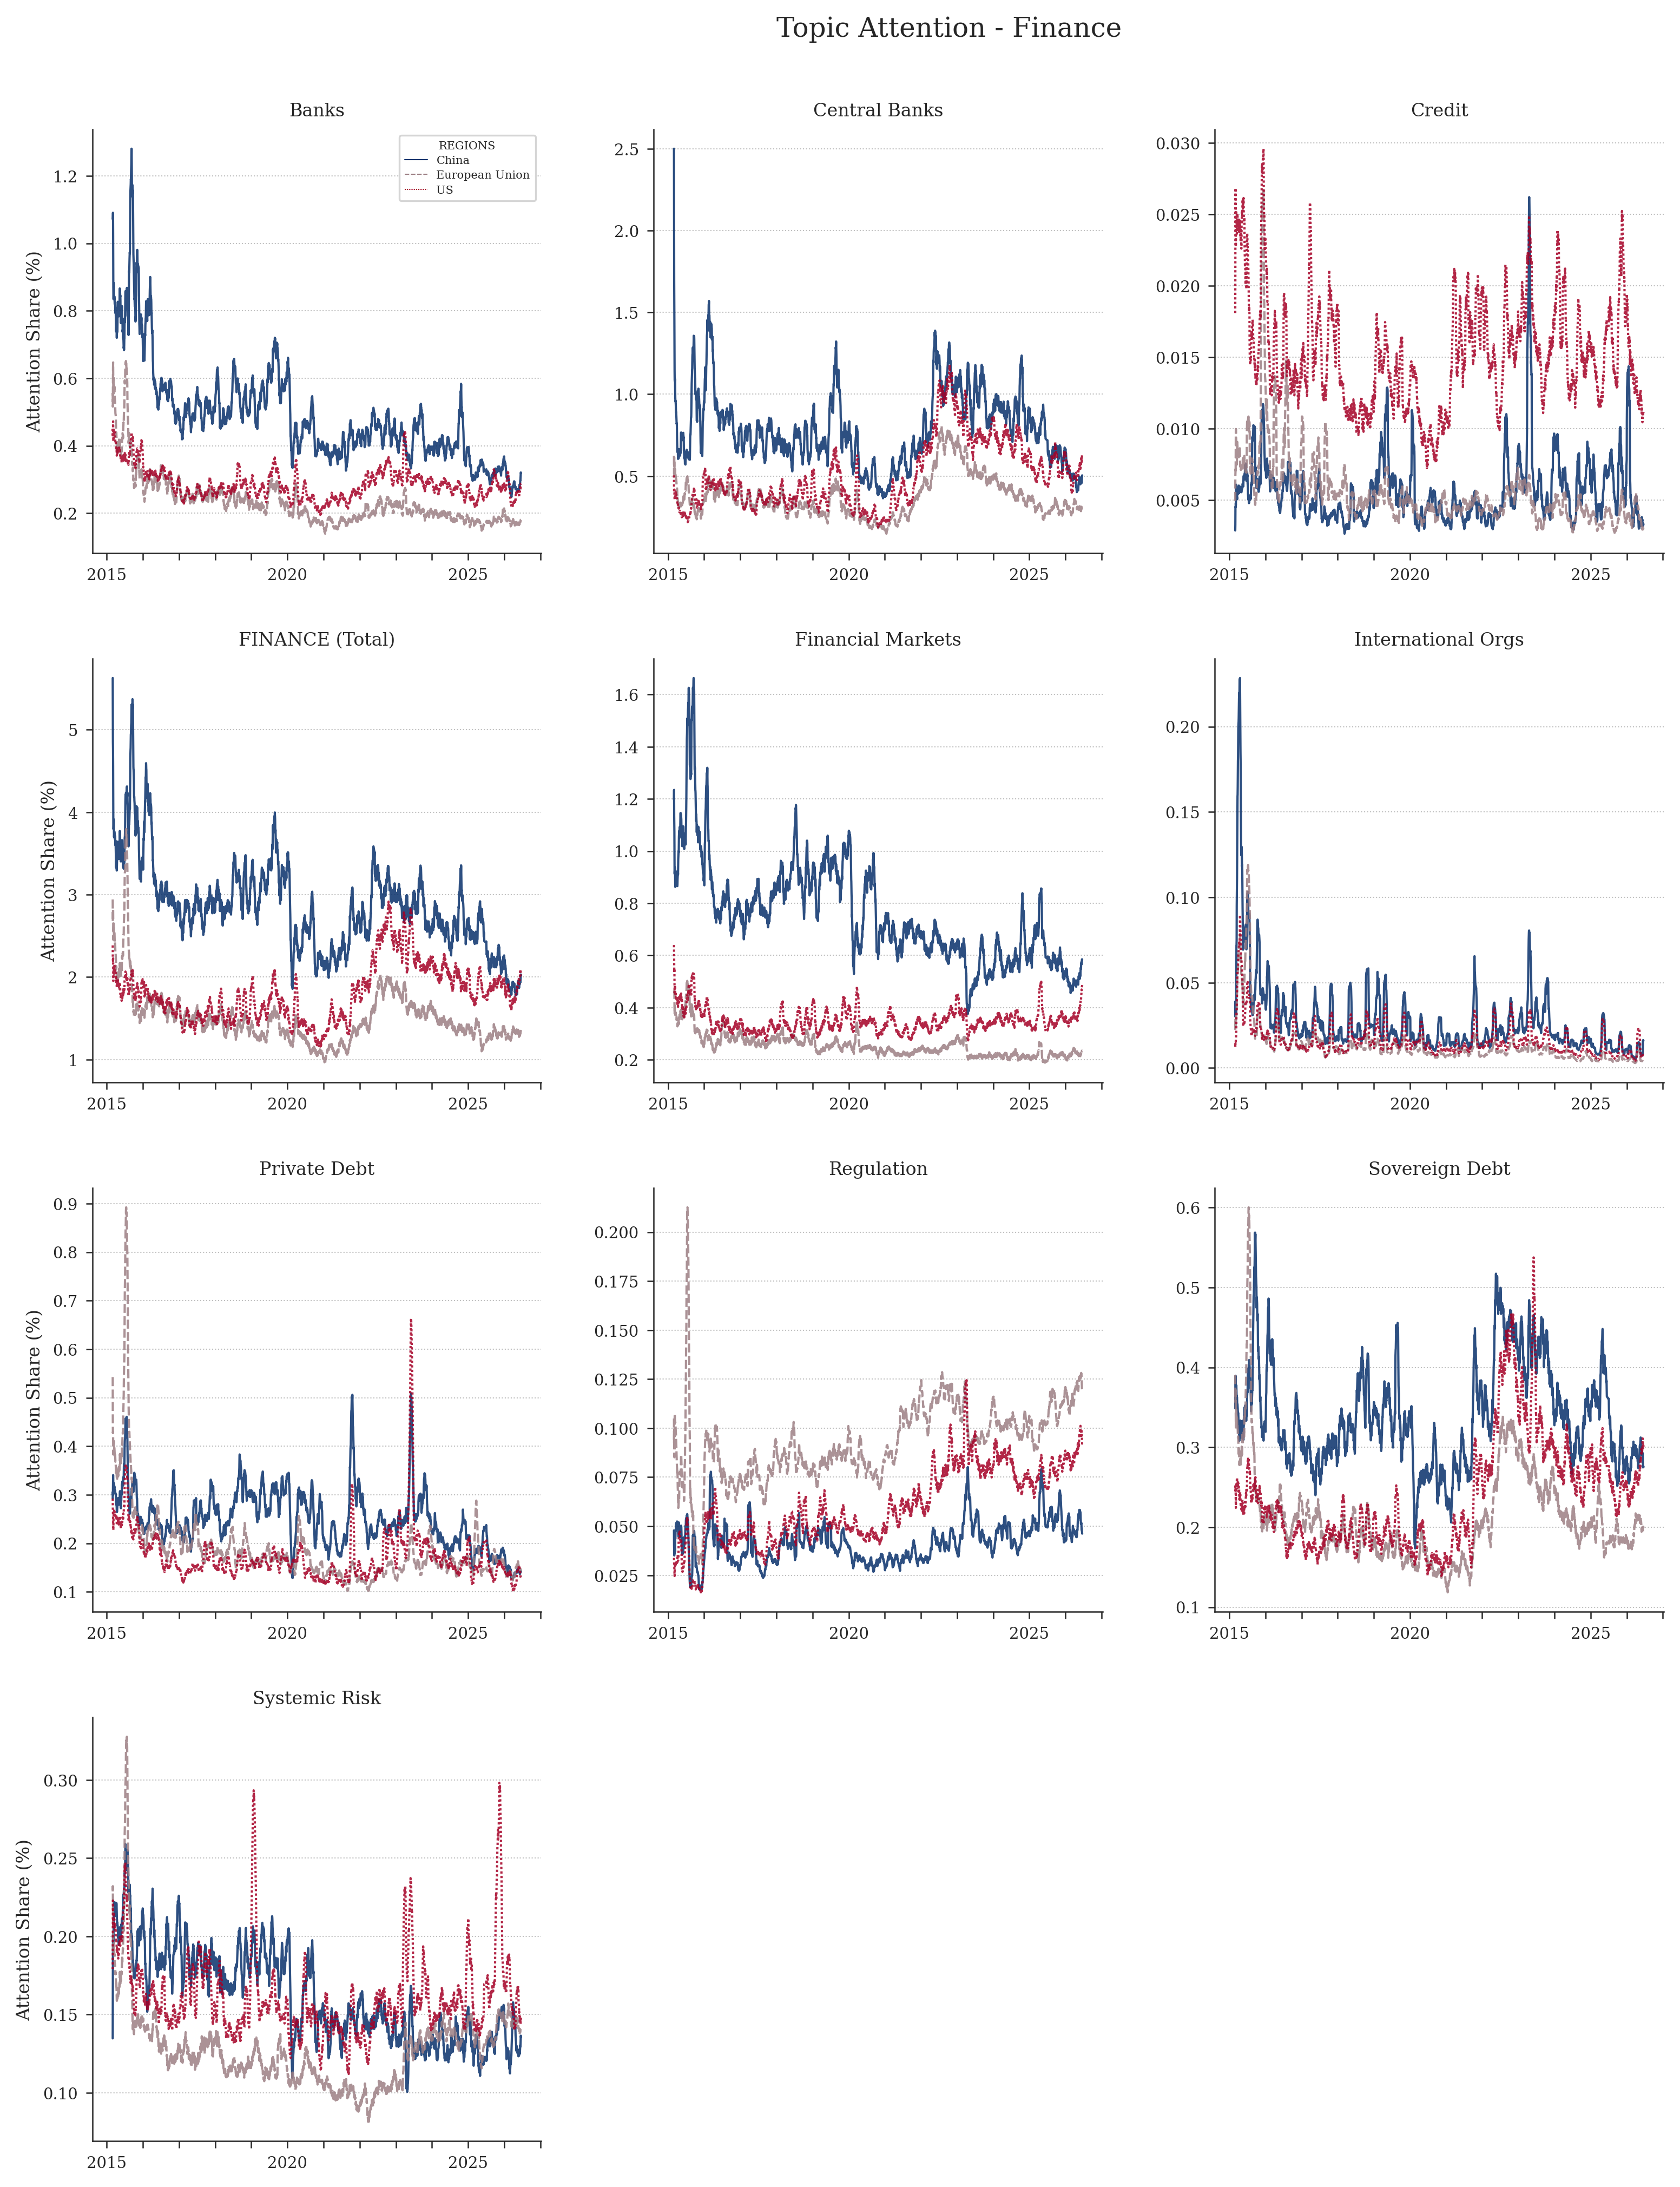

In [181]:
plot_academic_subsectors_grid(df_geo, sector_name="finance", regions=["US", "European Union", "China"], rolling_window=30, filename="./plots/attention_time_series/finance_subsectors.png")

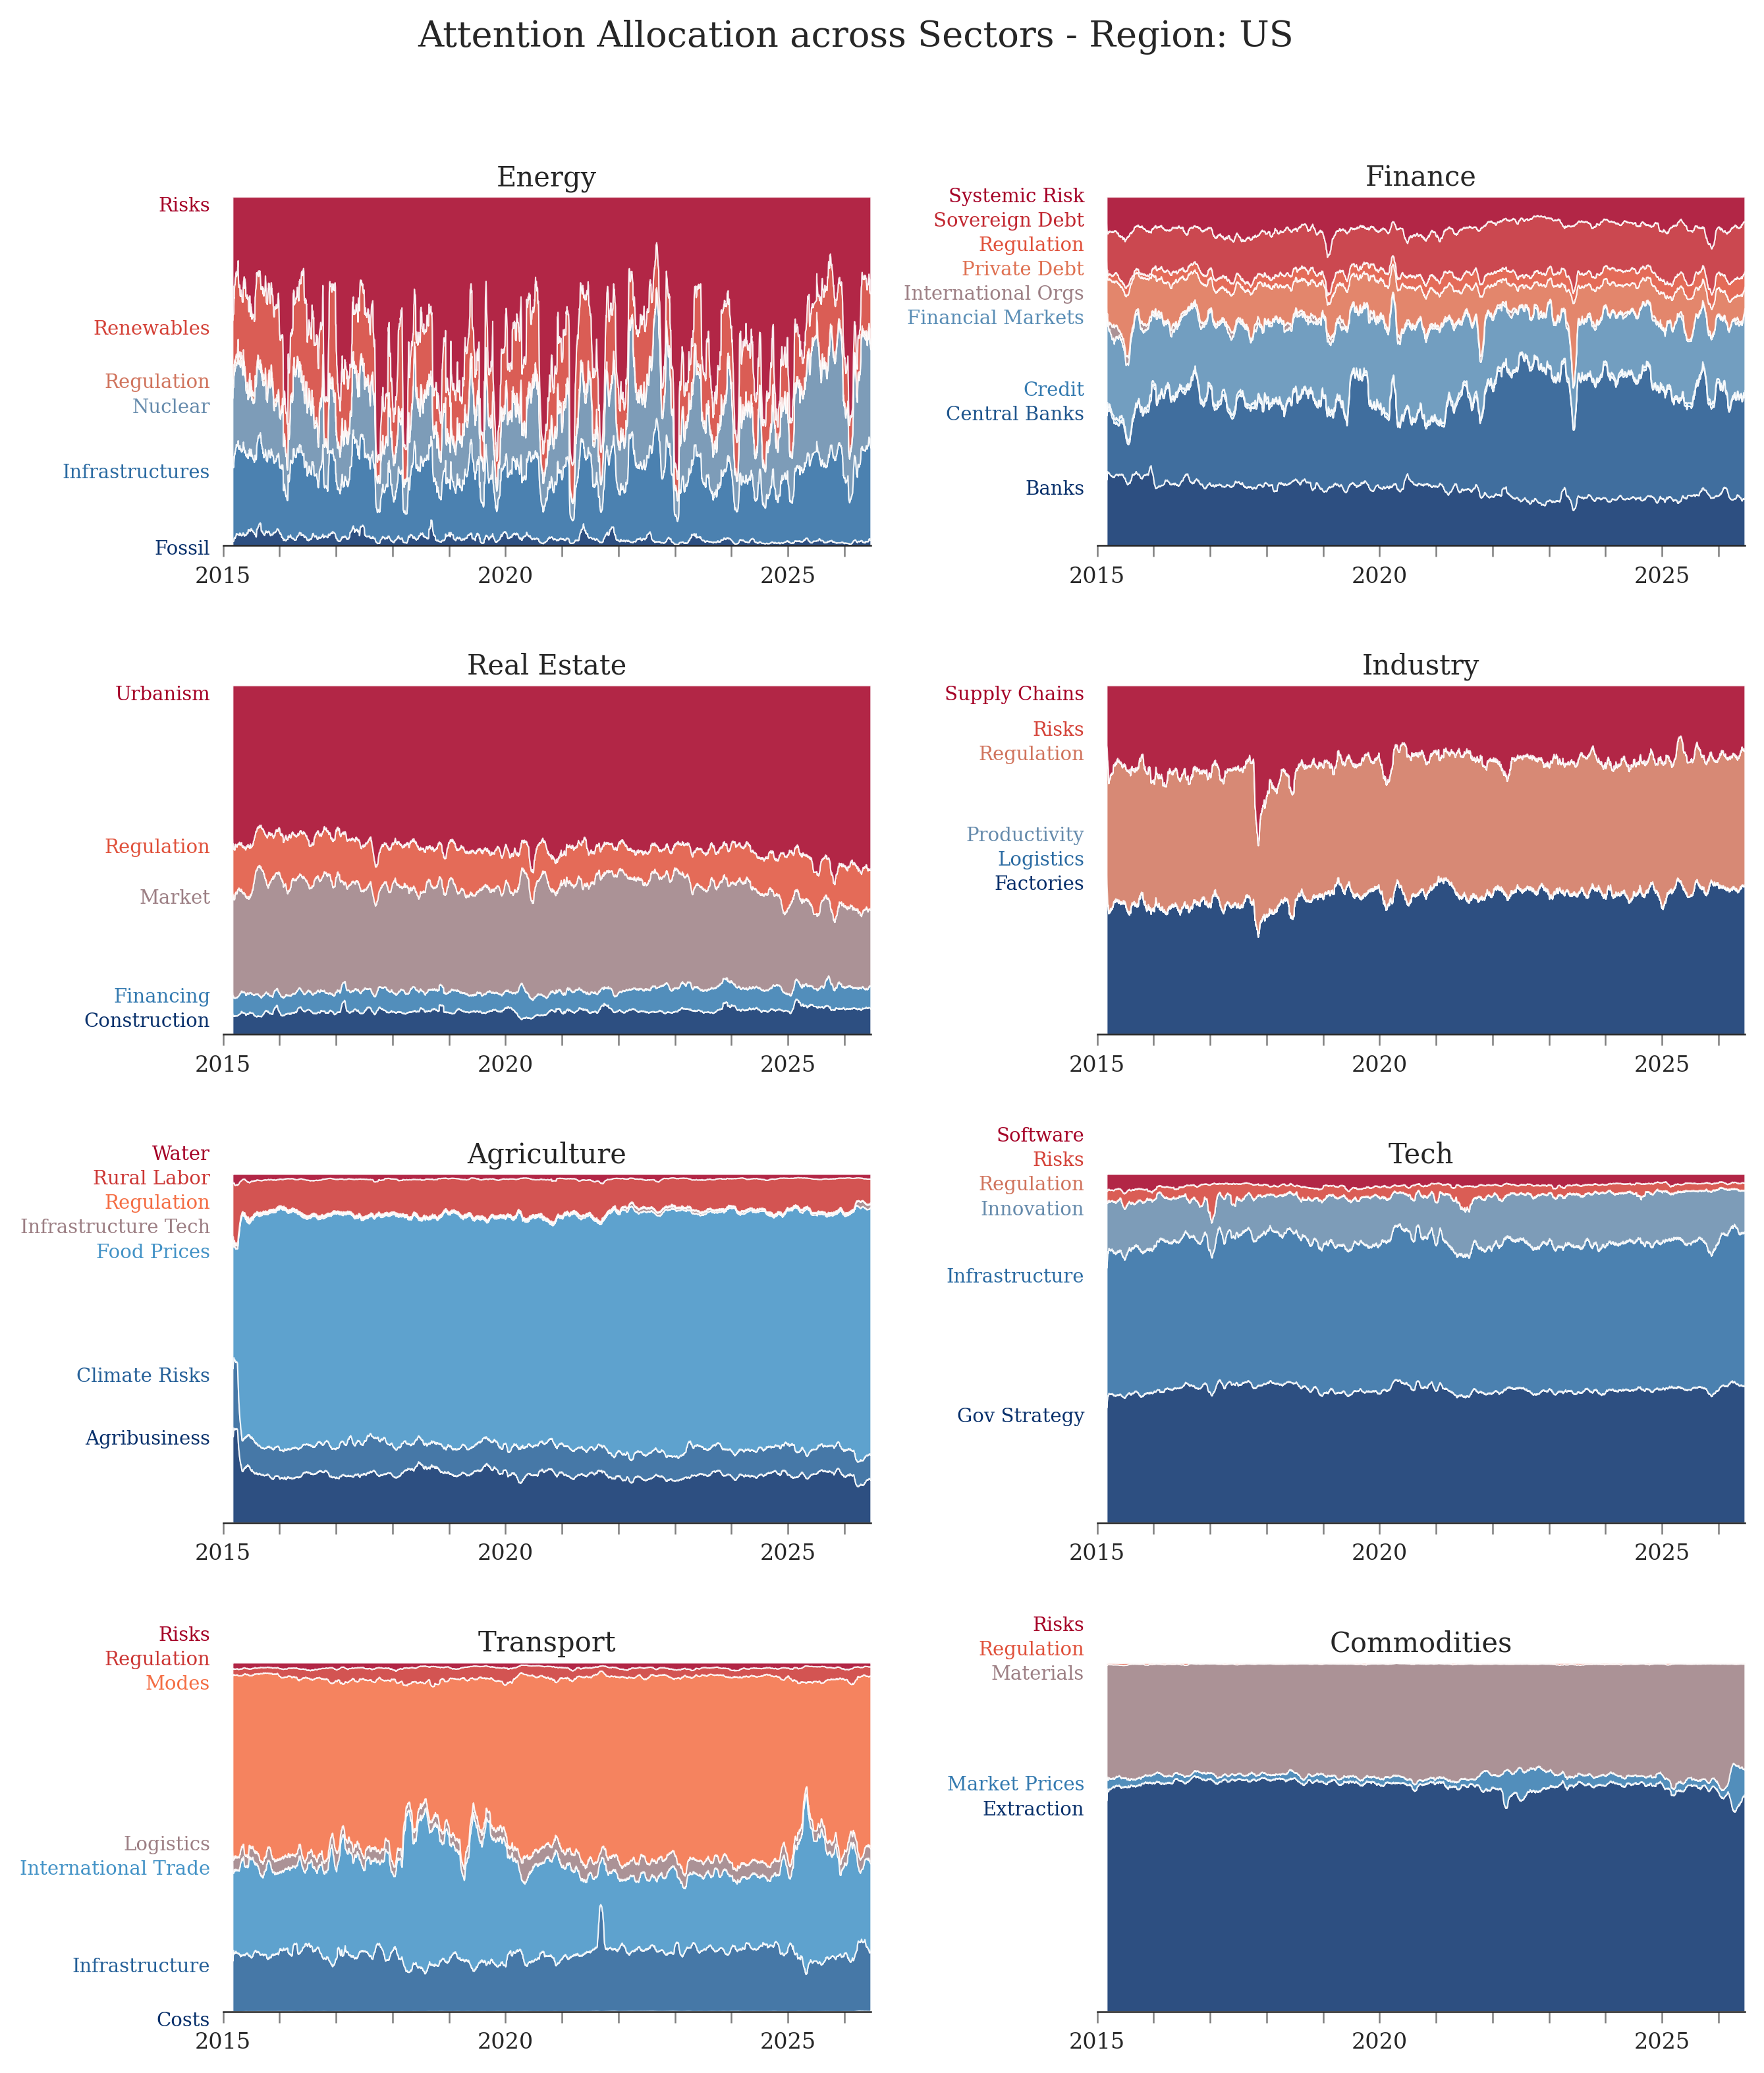

In [149]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

# ==============================================================================
# GRILLE ACADÉMIQUE : ALLOCATION DE L'ATTENTION PAR SECTEUR (1 RÉGION)
# ==============================================================================

# 🎯 Paramètres
target_region = "US"  # À modifier selon la région souhaitée
lissage_jours = 30

# Configuration du style académique (minimaliste, serif)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

# 1. Identifier dynamiquement les secteurs (noms composés gérés)
all_att_cols = [c for c in df_geo.columns if c.startswith('att_weight_')]

sectors_dict = {}
for col in all_att_cols:
    sector_candidate = col.replace('att_weight_', '')
    prefix = f"att_weight_{sector_candidate}_"
    subcats = [c for c in all_att_cols if c.startswith(prefix)]
    
    if len(subcats) > 0:
        sectors_dict[sector_candidate] = subcats

# 2. Préparation de la structure de la grille 
n_sectors = len(sectors_dict)
n_cols = 2
n_rows = int(np.ceil(n_sectors / n_cols))

# 🎯 MODIFICATION : Hauteur des lignes encore réduite (2.8 au lieu de 3.5)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.8 * n_rows), sharex=False)
axes = axes.flatten() if n_sectors > 1 else [axes]

# 3. Filtrage de la donnée pour la région cible
df_region = df_geo[df_geo['region_key'] == target_region].copy()
df_region = df_region.sort_values('period').set_index('period')

start_date = df_region.index.min()
end_date = df_region.index.max()

# Génération des tirets annuels et des labels sélectifs
annees_visibles = [2015, 2020, 2025]
toutes_les_annees = range(start_date.year, end_date.year + 1)

custom_ticks = [pd.to_datetime(f"{y}-01-01") for y in toutes_les_annees]
custom_labels = [str(y) if y in annees_visibles else "" for y in toutes_les_annees]

# 4. Génération des graphiques secteur par secteur
for idx, (sector, cols) in enumerate(sectors_dict.items()):
    ax = axes[idx]
    cols = sorted(cols)
    
    prefix_to_remove = f"att_weight_{sector}_"
    labels = [c.replace(prefix_to_remove, '').replace('_', ' ').title() for c in cols]
    
    df_smooth = df_region[cols].fillna(0).rolling(window=lissage_jours, min_periods=1).mean().fillna(0)
    
    total = df_smooth.sum(axis=1).replace(0, np.nan)
    df_norm = df_smooth.div(total, axis=0).fillna(0)
    
    colors = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(cols))
    
    ax.stackplot(
        df_norm.index, 
        df_norm.T, 
        colors=colors,
        alpha=0.85,
        linewidth=0.5,
        edgecolor='white'
    )
    
    # 🎯 MODIFICATION : Plus de gras, titre légèrement plus petit, espacement réduit (pad=4)
    ax.set_title(sector.replace('_', ' ').title(), fontweight='normal', fontsize=10, pad=4)
    ax.set_ylim(0, 1)
    ax.set_xlim(start_date, end_date)
    ax.margins(x=0)
    ax.set_yticks([]) 
    
    if len(df_norm) > 0:
        first_day_values = df_norm.iloc[0].values
        cumulative_heights = np.cumsum(first_day_values)
        
        y_positions = list(cumulative_heights)
        # Gap réduit pour s'adapter à la plus petite police
        min_gap = 0.07 
        for i in range(1, len(y_positions)):
            if y_positions[i] - y_positions[i-1] < min_gap:
                y_positions[i] = y_positions[i-1] + min_gap
        
        for i, label in enumerate(labels):
            ax.text(
                -0.02, y_positions[i], 
                label, 
                color=colors[i], 
                fontsize=7, # 🎯 Légendes plus discrètes
                fontweight='normal', # 🎯 Suppression du gras
                ha='right', 
                va='top',
                transform=ax.transAxes 
            )
        
    # APPLICATION DES DATES SUR L'AXE X (Sans gras, discrets)
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels(custom_labels)
    ax.tick_params(axis='x', direction='out', length=4, labelsize=8, color='gray', labelbottom=True)

# 5. Nettoyage des cases vides
for idx in range(n_sectors, len(axes)):
    fig.delaxes(axes[idx])

# 🎯 MODIFICATION : Titre global sans gras et rabaissé plus près des graphiques (y=0.96)
fig.suptitle(f"Attention Allocation across Sectors - Region: {target_region}", 
             fontsize=13, fontweight='normal', y=0.96)

# 🎯 MODIFICATION : hspace réduit pour des blocs plus compacts, top abaissé
plt.subplots_adjust(left=0.18, right=0.95, top=0.88, bottom=0.06, hspace=0.40, wspace=0.35)
plt.show()

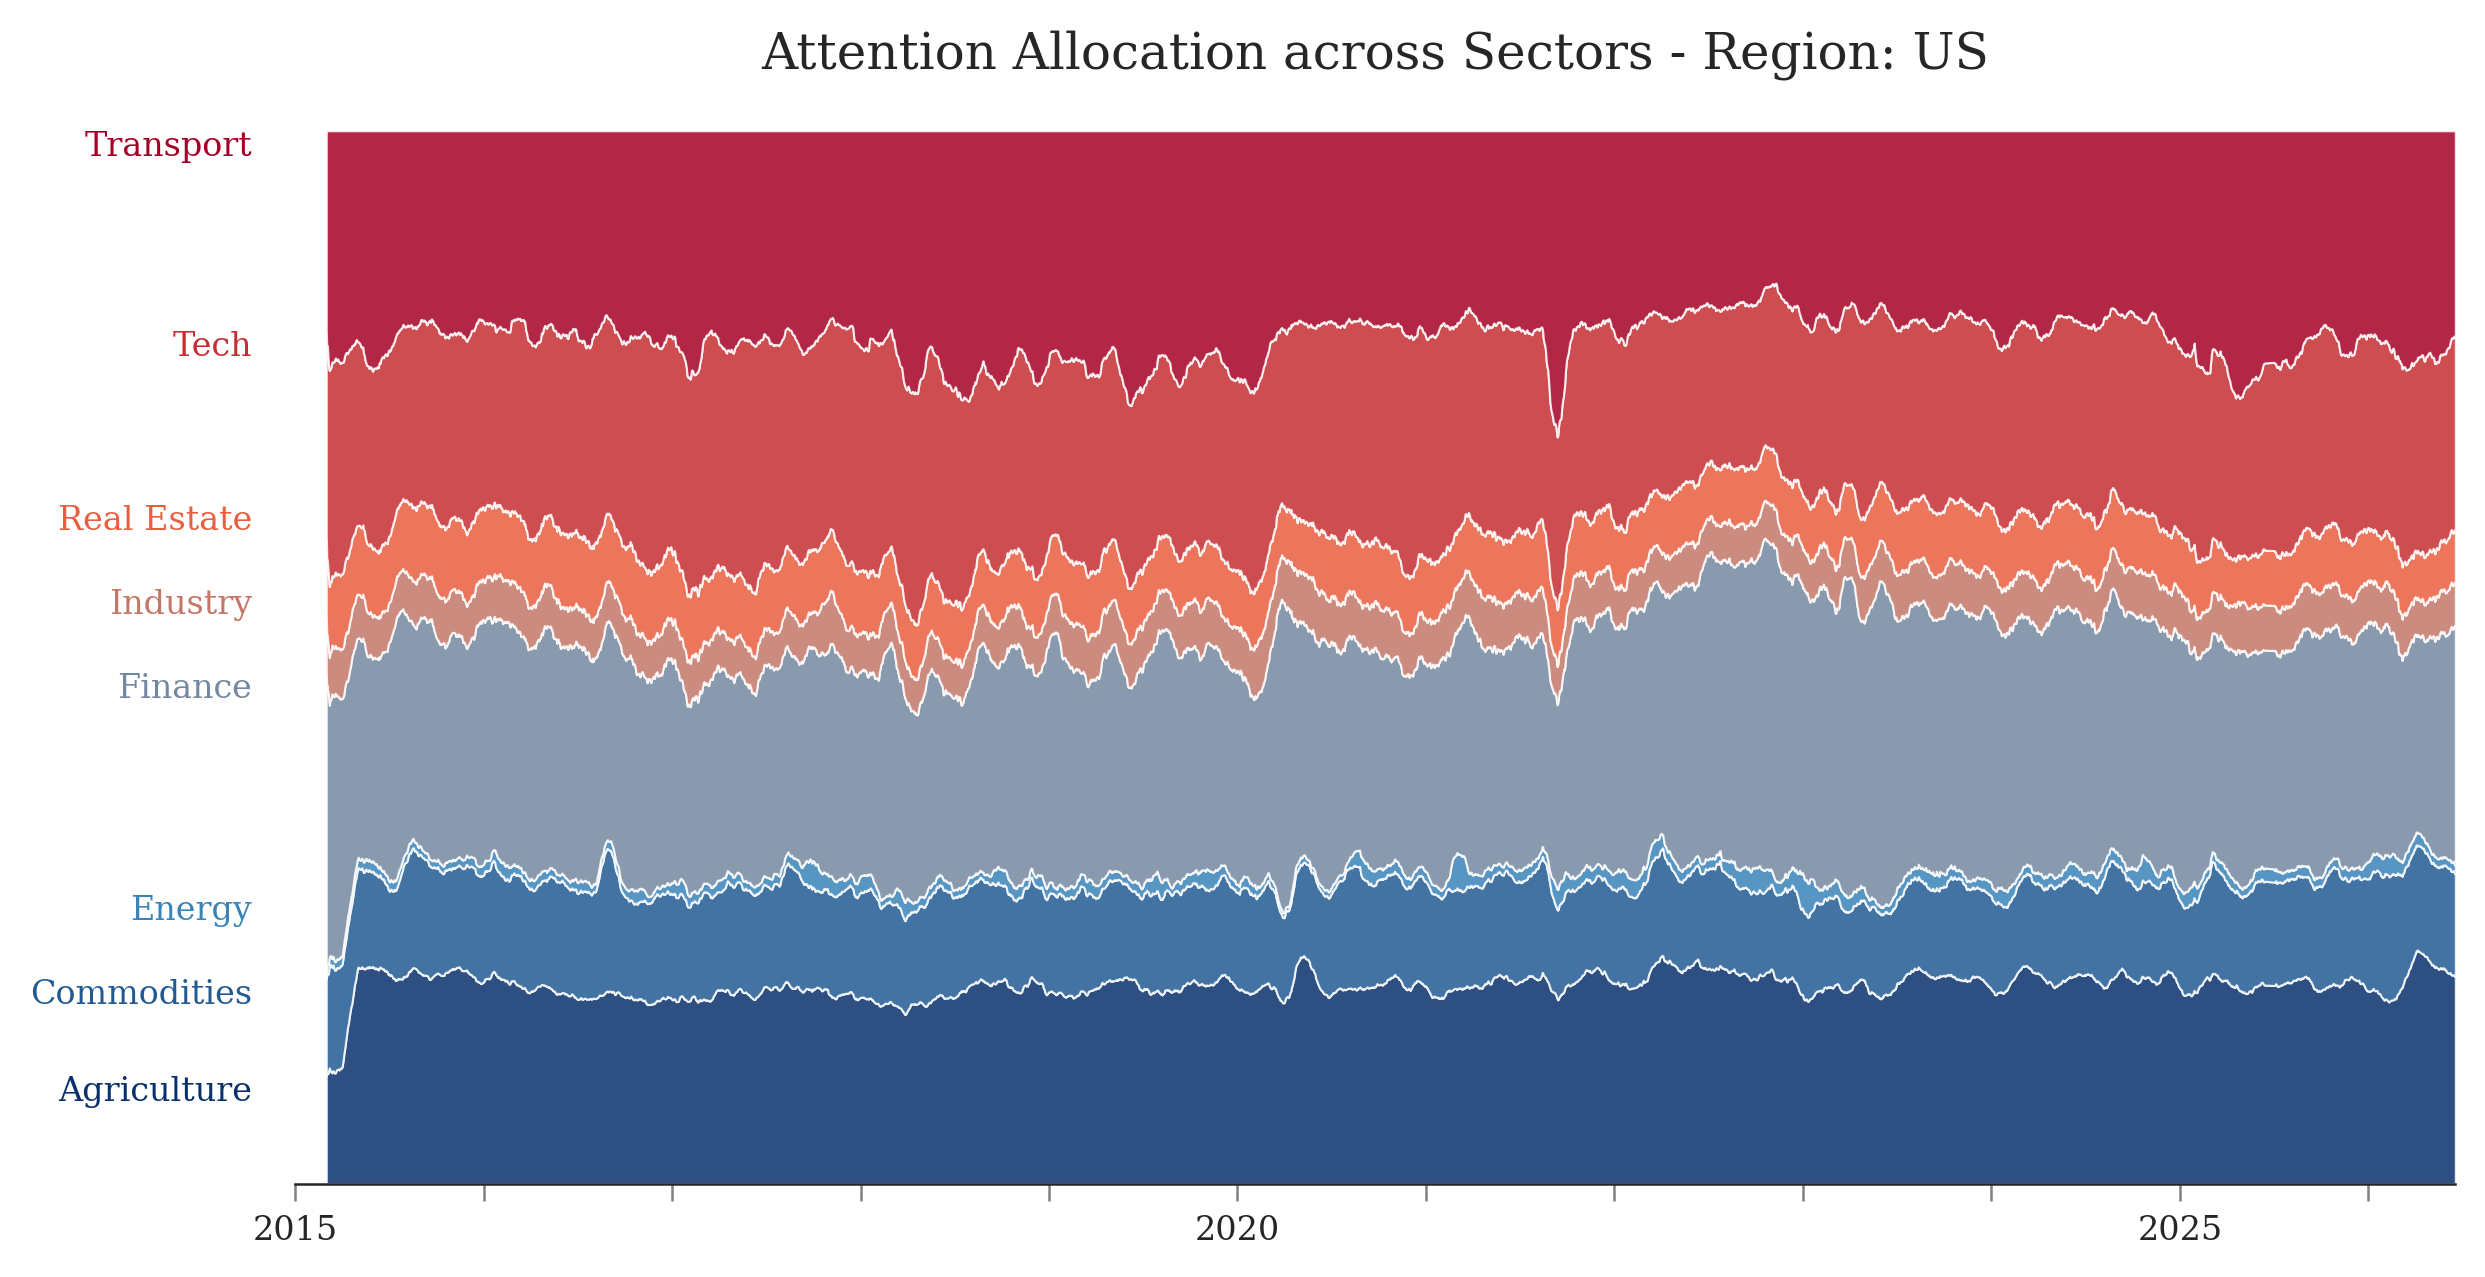

In [152]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd

# ==============================================================================
# GRAPHIQUE UNIQUE : ALLOCATION DE L'ATTENTION MACRO (LES 8 SECTEURS)
# ==============================================================================

# 🎯 Paramètres
target_region = "US"  
lissage_jours = 30

# Configuration du style académique (minimaliste, serif)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

# 1. Identifier dynamiquement les 8 grands secteurs
all_att_cols = [c for c in df_geo.columns if c.startswith('att_weight_')]
macro_sectors = []

# On déduit les secteurs globaux : ce sont ceux qui possèdent des sous-catégories
for col in all_att_cols:
    sector_candidate = col.replace('att_weight_', '')
    prefix = f"att_weight_{sector_candidate}_"
    subcats = [c for c in all_att_cols if c.startswith(prefix)]
    
    if len(subcats) > 0:
        macro_sectors.append(sector_candidate)

# Tri alphabétique pour une cohérence des couleurs et préparation des colonnes exactes
macro_sectors = sorted(macro_sectors)
macro_cols = [f"att_weight_{s}" for s in macro_sectors]
labels = [s.replace('_', ' ').title() for s in macro_sectors]

# 2. Préparation du graphique unique (Compact et allongé)
fig, ax = plt.subplots(figsize=(9, 4.5))

# 3. Filtrage de la donnée
df_region = df_geo[df_geo['region_key'] == target_region].copy()
df_region = df_region.sort_values('period').set_index('period')

start_date = df_region.index.min()
end_date = df_region.index.max()

# Génération des tirets annuels
annees_visibles = [2015, 2020, 2025]
toutes_les_annees = range(start_date.year, end_date.year + 1)
custom_ticks = [pd.to_datetime(f"{y}-01-01") for y in toutes_les_annees]
custom_labels = [str(y) if y in annees_visibles else "" for y in toutes_les_annees]

# 4. Traitement des données (Lissage et Normalisation)
df_smooth = df_region[macro_cols].fillna(0).rolling(window=lissage_jours, min_periods=1).mean().fillna(0)

# On recalcule le 100% basé uniquement sur la somme de ces 8 secteurs macroscopiques
total = df_smooth.sum(axis=1).replace(0, np.nan)
df_norm = df_smooth.div(total, axis=0).fillna(0)

# Camaïeu académique étiré sur les 8 secteurs
colors = sns.blend_palette(["#08306b", "#4292c6", "#f46d43", "#a50026"], len(macro_cols))

# 5. Tracé des aires empilées
ax.stackplot(
    df_norm.index, 
    df_norm.T, 
    colors=colors,
    alpha=0.85,
    linewidth=0.5,
    edgecolor='white'
)

# Esthétique du graphique (zéro gras)
ax.set_title(f"Attention Allocation across Sectors - Region: {target_region}", 
             fontweight='normal', fontsize=12, pad=15)
ax.set_ylim(0, 1)
ax.set_xlim(start_date, end_date)
ax.margins(x=0)
ax.set_yticks([]) 

# 6. Alignement physique des étiquettes à gauche
if len(df_norm) > 0:
    first_day_values = df_norm.iloc[0].values
    cumulative_heights = np.cumsum(first_day_values)
    
    y_positions = list(cumulative_heights)
    min_gap = 0.08  # Espace minimum entre deux mots pour éviter la collision
    for i in range(1, len(y_positions)):
        if y_positions[i] - y_positions[i-1] < min_gap:
            y_positions[i] = y_positions[i-1] + min_gap
    
    for i, label in enumerate(labels):
        ax.text(
            -0.02, y_positions[i], 
            label, 
            color=colors[i], 
            fontsize=8,           # Discret
            fontweight='normal',  # Pas de gras
            ha='right', 
            va='top',
            transform=ax.transAxes 
        )
    
# 7. Axes temporels
ax.set_xticks(custom_ticks)
ax.set_xticklabels(custom_labels)
ax.tick_params(axis='x', direction='out', length=4, labelsize=8, color='gray')

# 8. Ajustement pour laisser de la place à la marge gauche (étiquettes)
plt.subplots_adjust(left=0.18, right=0.98, top=0.90, bottom=0.12)
plt.show()

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_regional_correlation_matrix(df_geo, target_region, metric_prefix="att_weight", rolling_window=30, filename="Fig_Correlation_Matrix.pdf"):
    """
    Génère une matrice de corrélation académique (triangulaire) de tous les sous-secteurs pour une région donnée.
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE 
    # ==========================================
    sns.set_theme(style="white", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. PRÉPARATION DES DONNÉES
    # ==========================================
    # Filtrage de la région
    df_region = df_geo[df_geo['region_key'] == target_region].copy()
    
    if df_region.empty:
        print(f"⚠ Aucune donnée trouvée pour la région '{target_region}'.")
        return
        
    df_region = df_region.sort_values('period').set_index('period')

    # Identification de TOUS les sous-secteurs (colonnes avec au moins 3 underscores)
    subcat_cols = sorted([c for c in df_region.columns if c.startswith(f"{metric_prefix}_") and c.count('_') >= 3])
    
    if not subcat_cols:
        print(f"⚠ Aucun sous-secteur trouvé avec le préfixe '{metric_prefix}_'.")
        return

    # Nettoyage des noms pour l'affichage (ex: 'att_weight_finance_banks' -> 'Finance Banks')
    def clean_name(col):
        parts = col.split('_')[2:] # Ignore 'att_weight'
        return " ".join(parts).title()
    
    clean_labels = [clean_name(c) for c in subcat_cols]

    # Lissage (Rolling Mean) : On corrèle les tendances, pas le bruit quotidien
    df_smooth = df_region[subcat_cols].fillna(0).rolling(window=rolling_window, min_periods=1).mean().fillna(0)
    
    # Renommer les colonnes du DataFrame lissé pour que la matrice affiche les beaux noms
    df_smooth.columns = clean_labels

    # Calcul de la matrice de corrélation (Pearson)
    corr_matrix = df_smooth.corr()

    # ==========================================
    # 3. TRACÉ DE LA MATRICE
    # ==========================================
    # Création d'un masque pour cacher le triangle supérieur (redondant)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Configuration de la figure (assez grande pour ~40 variables)
    fig, ax = plt.subplots(figsize=(12, 10))

    # Palette divergente académique (Rouge pour positif, Bleu pour négatif)
    cmap = sns.diverging_palette(250, 15, s=90, l=45, n=256, as_cmap=True)

    # Dessin de la Heatmap
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap=cmap, 
        vmax=1.0, vmin=-1.0, center=0,
        square=True, 
        linewidths=.5,           # Lignes blanches fines entre les cases
        cbar_kws={"shrink": .6, "label": f"Pearson Correlation (Smoothed {rolling_window}d)"}, 
        ax=ax
    )

    # Finitions esthétiques
    ax.set_title(f"Narrative Co-movement: Sub-sectors Correlation Matrix - Region: {target_region}", 
                 pad=20, fontweight="normal")
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Ajustement des marges
    plt.subplots_adjust(bottom=0.25, left=0.25)
    
    # ==========================================
    # 4. EXPORT
    # ==========================================
    plt.savefig(filename)
    print(f"✔ Matrice de corrélation sauvegardée sous : {filename}")
    plt.show()

# ==============================================================================
# EXEMPLE D'UTILISATION
# ==============================================================================
# plot_regional_correlation_matrix(df_geo, target_region="US", rolling_window=30)

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd

def plot_academic_correlation_clusters(df_geo, target_region, metric_prefix="att_weight", rolling_window=30, filename="Fig_Correlation_Clusters.pdf"):
    """
    Génère une matrice de corrélation académique (triangulaire) de tous les sous-secteurs.
    🔥 Les variables sont réorganisées par clustering hiérarchique pour révéler les blocs de co-mouvement.
    """
    # ==========================================
    # 1. CONFIGURATION ESTHÉTIQUE 
    # ==========================================
    sns.set_theme(style="white", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight"
    })

    # ==========================================
    # 2. PRÉPARATION DES DONNÉES
    # ==========================================
    df_region = df_geo[df_geo['region_key'] == target_region].copy()
    if df_region.empty:
        print(f"⚠ Aucune donnée trouvée pour la région '{target_region}'.")
        return
        
    df_region = df_region.sort_values('period').set_index('period')

    subcat_cols = sorted([c for c in df_region.columns if c.startswith(f"{metric_prefix}_") and c.count('_') >= 3])
    if not subcat_cols: return

    def clean_name(col):
        parts = col.split('_')[2:]
        return " ".join(parts).title()
    
    clean_labels = [clean_name(c) for c in subcat_cols]

    # Lissage des tendances
    df_smooth = df_region[subcat_cols].fillna(0).rolling(window=rolling_window, min_periods=1).mean().fillna(0)
    df_smooth.columns = clean_labels

    # Calcul de la matrice de corrélation brute
    # 1. Calcul de la matrice de corrélation
    corr_matrix = df_smooth.corr().fillna(0)

    # 2. Clustering
    dist_matrix = 1 - corr_matrix.values
    dist_condensed = ssd.squareform(dist_matrix, checks=False)
    linkage = sch.linkage(dist_condensed, method='ward')
    cluster_order = sch.leaves_list(linkage)
    
    # 3. 🔥 LA CORRECTION CLÉ : On réordonne proprement le DataFrame avec ses vrais labels
    ordered_cols = corr_matrix.columns[cluster_order]
    corr_matrix_clustered = corr_matrix.loc[ordered_cols, ordered_cols]

    # 4. Tracé
    mask = np.triu(np.ones_like(corr_matrix_clustered, dtype=bool))
    fig, ax = plt.subplots(figsize=(12, 10))
    cmap = sns.diverging_palette(250, 15, s=90, l=45, n=256, as_cmap=True)

    sns.heatmap(
        corr_matrix_clustered, 
        mask=mask, 
        cmap=cmap, 
        vmax=1.0, vmin=-1.0, center=0,
        square=True, 
        linewidths=.5,           
        cbar_kws={"shrink": .6, "label": f"Pearson Correlation (Clustered, Smoothed {rolling_window}d)"}, 
        ax=ax
    )

    # 🔥 On applique explicitement les labels ordonnés aux axes
    ax.set_xticks(np.arange(len(ordered_cols)) + 0.5)
    ax.set_yticks(np.arange(len(ordered_cols)) + 0.5)
    ax.set_xticklabels(ordered_cols, rotation=45, ha='right', rotation_mode='anchor')
    ax.set_yticklabels(ordered_cols, rotation=0)

    ax.set_title(f"Latent Topics: Hierarchically Clustered Correlation Matrix - {target_region}", 
                 pad=20, fontweight="normal")

    plt.subplots_adjust(bottom=0.25, left=0.25)
    plt.savefig(filename)
    plt.show()

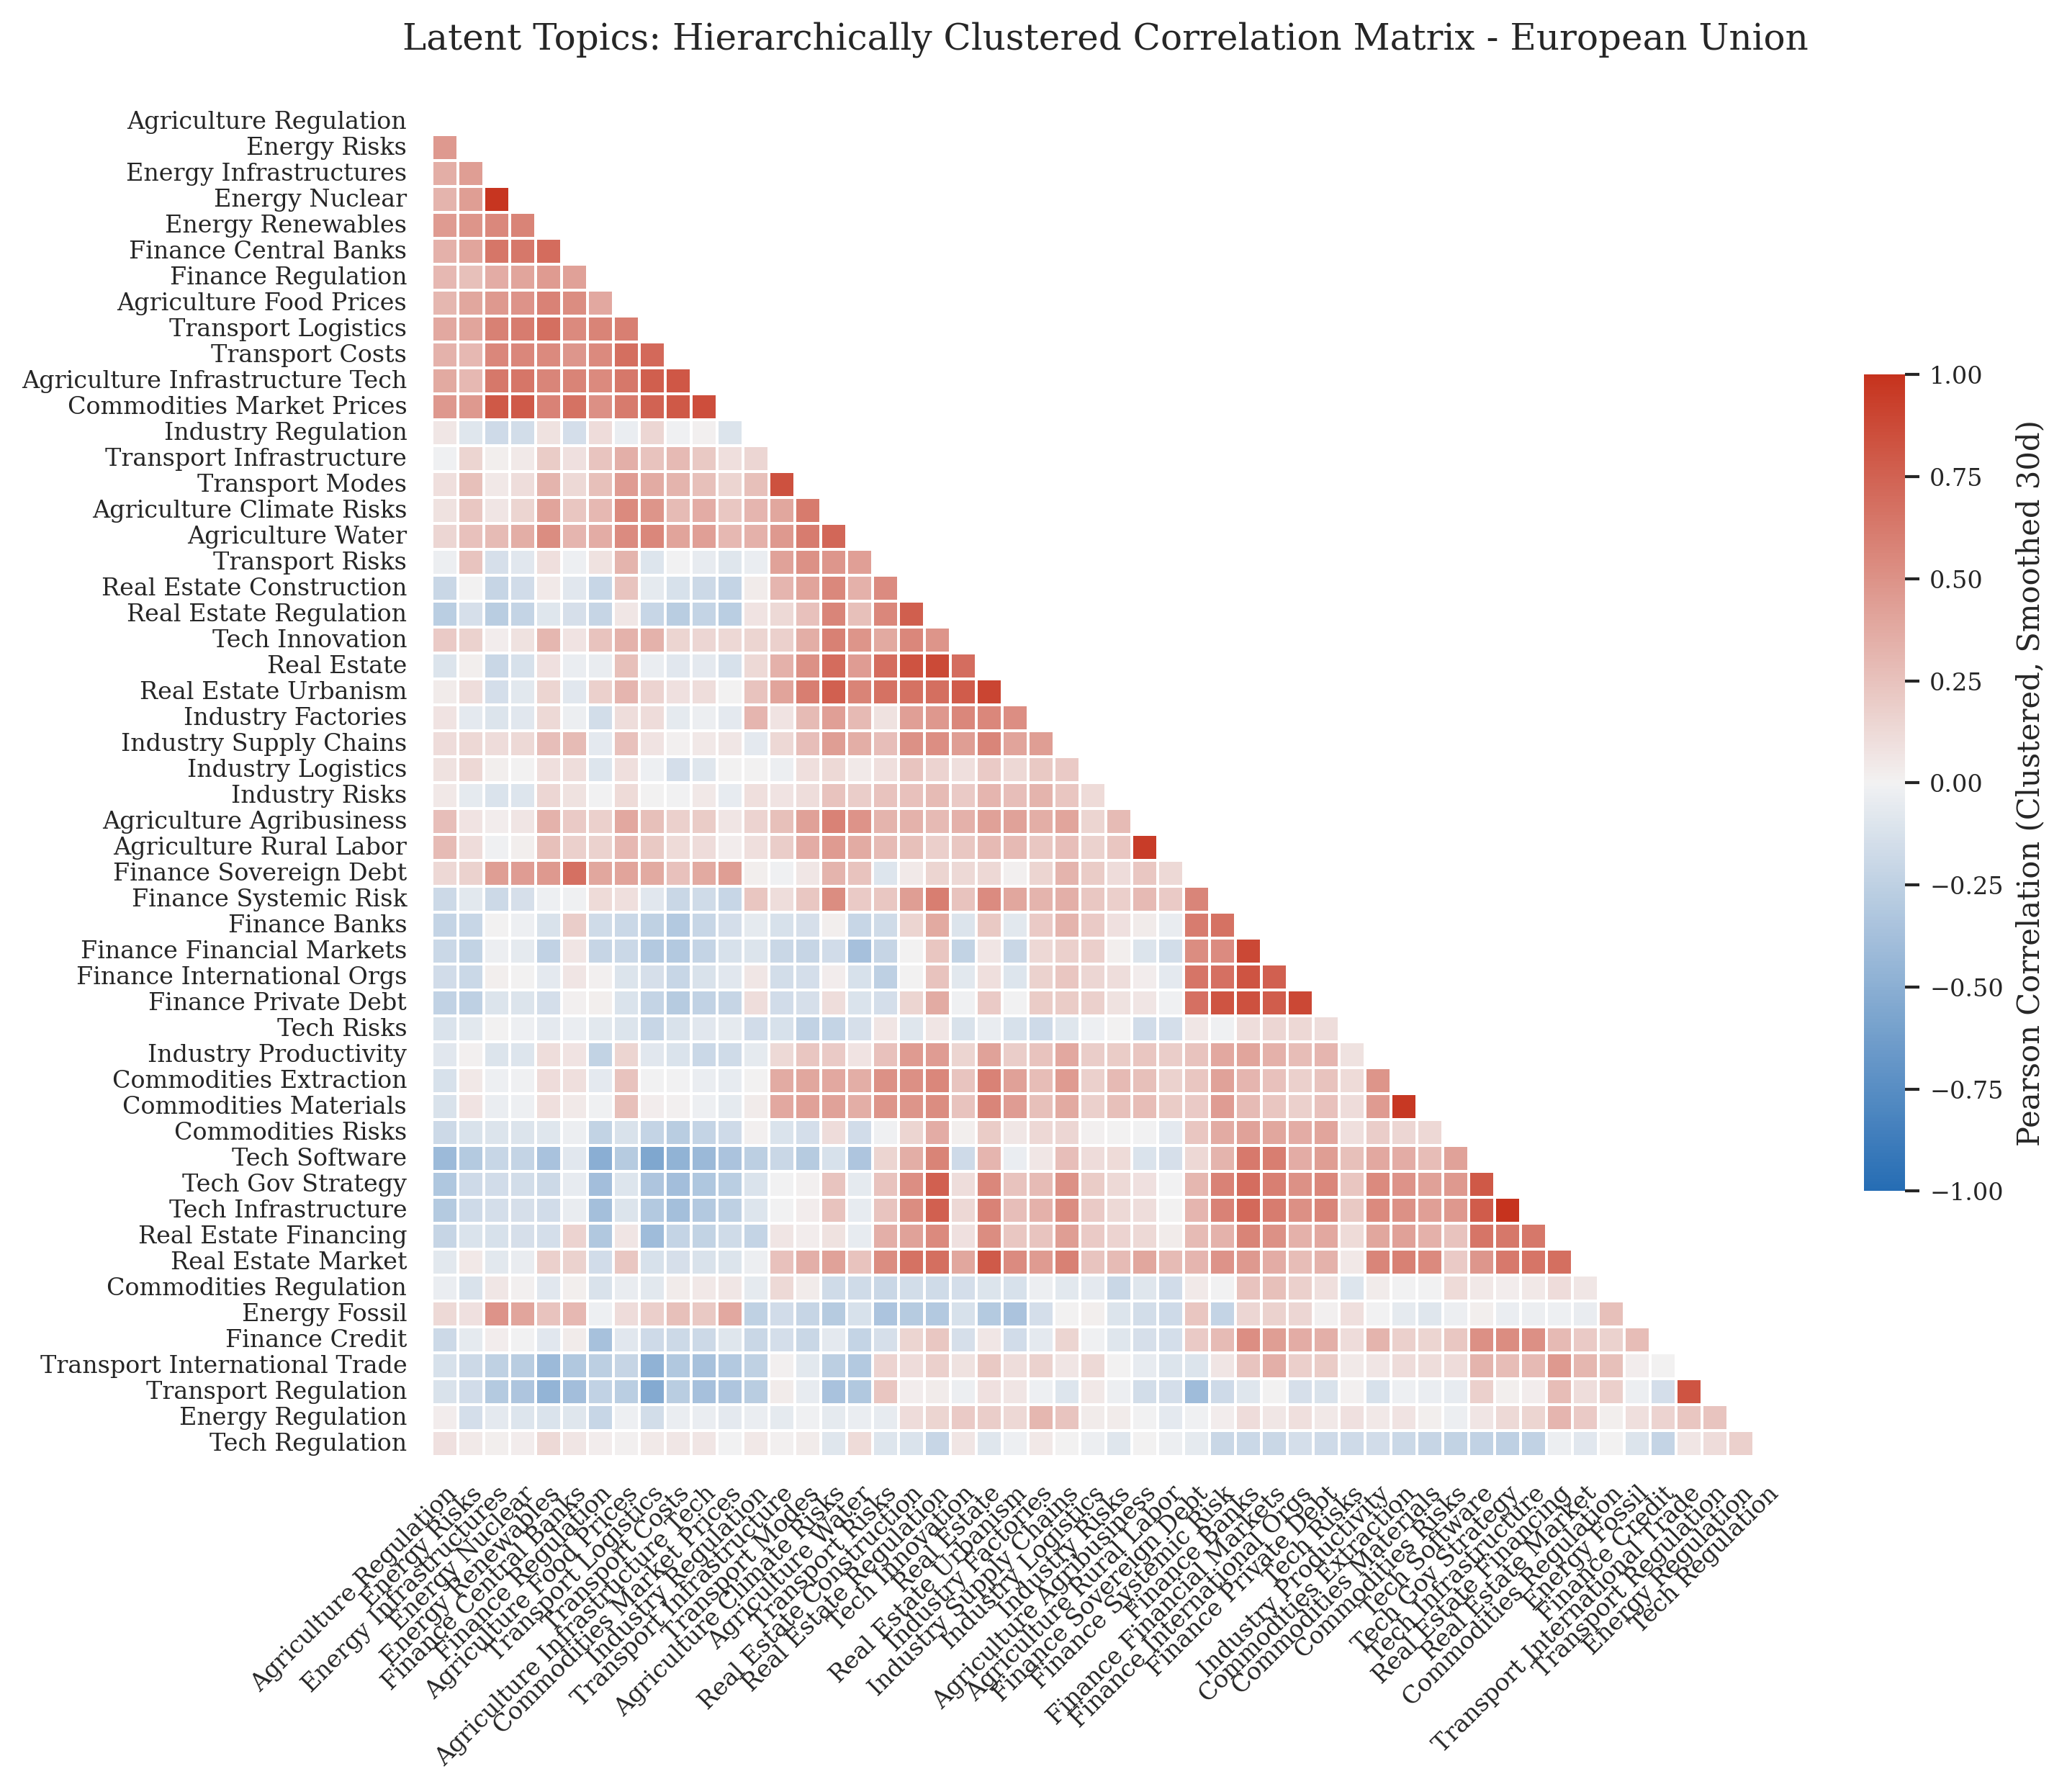

In [188]:
plot_academic_correlation_clusters(df_geo, target_region="European Union", rolling_window=30)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import matplotlib.gridspec as gridspec

def plot_bybee_tsne_articles(df_articles, topic_cols, sample_size=30000, filename="Fig_Bybee_tSNE.pdf"):
    """
    Reproduit la Figure 16 de Bybee et al. (2024) :
    Projection t-SNE des articles, colorés par leur sujet dominant.
    - Haut : Tous les articles
    - Bas gauche : Articles Purs (Poids Max > 33%)
    - Bas droite : Articles Mixtes (Poids Max < 25%)
    
    df_articles : DataFrame contenant les articles individuels (1 ligne = 1 article).
    topic_cols : Liste des colonnes contenant les proportions thématiques.
    """
    print(f"\n{'='*70}\n🚀 PROJECTION t-SNE DES NARRATIFS (Façon Bybee et al.)\n{'='*70}")
    
    # ====================================================
    # 1. ÉCHANTILLONNAGE ET PRÉPARATION DES DONNÉES
    # ====================================================
    # Le t-SNE est O(N^2), il est impératif d'échantillonner
    if len(df_articles) > sample_size:
        print(f"1. Échantillonnage de {len(df_articles)} vers {sample_size} articles pour le calcul...")
        df_sample = df_articles.sample(n=sample_size, random_state=42).copy()
    else:
        df_sample = df_articles.copy()
        
    # S'assurer que les colonnes sont des proportions (somme = 1) si ce n'est pas le cas
    # df_sample[topic_cols] = df_sample[topic_cols].div(df_sample[topic_cols].sum(axis=1), axis=0)

    print("2. Calcul du Sujet Dominant et de la Pureté...")
    # Trouver la valeur maximale d'attention pour chaque article
    df_sample['max_proportion'] = df_sample[topic_cols].max(axis=1)
    
    # Trouver le nom du sujet dominant
    df_sample['dominant_topic'] = df_sample[topic_cols].idxmax(axis=1)
    # Nettoyage du nom pour la légende (enlève 'att_weight_')
    df_sample['dominant_topic'] = df_sample['dominant_topic'].str.replace('att_weight_', '', regex=False)

    # Définition des masques de pureté selon Bybee
    mask_pure = df_sample['max_proportion'] > 0.33
    mask_mixed = df_sample['max_proportion'] < 0.25

    # ====================================================
    # 2. RÉDUCTION DE DIMENSION (t-SNE)
    # ====================================================
    print("3. Calcul de la projection t-SNE (cela peut prendre quelques minutes)...")
    # perplexity=40 est un bon standard pour les NLP. n_jobs=-1 utilise tous les cœurs du CPU.
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1, init='pca')
    embedding = tsne.fit_transform(df_sample[topic_cols])
    
    df_sample['tsne_1'] = embedding[:, 0]
    df_sample['tsne_2'] = embedding[:, 1]
    
    # ====================================================
    # 3. TRACÉ DES GRAPHIQUES (GRIDSPEC)
    # ====================================================
    print("4. Génération de la figure académique...")
    # Configuration esthétique globale
    plt.rcParams.update({"font.family": "serif", "figure.dpi": 300})
    sns.set_theme(style="white") # Fond blanc pour bien voir les couleurs
    
    # Création d'une palette de couleurs avec suffisamment de couleurs distinctes
    unique_topics = df_sample['dominant_topic'].unique()
    palette = sns.color_palette("husl", len(unique_topics))
    color_map = dict(zip(unique_topics, palette))

    fig = plt.figure(figsize=(12, 14))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1])
    
    # Paramètres communs pour les scatter plots
    scatter_kws = {'s': 0.5, 'alpha': 0.6, 'edgecolor': 'none'}
    
    # --- GRAPHIQUE HAUT : TOUS LES ARTICLES ---
    ax_top = fig.add_subplot(gs[0, :])
    sns.scatterplot(
        data=df_sample, x='tsne_1', y='tsne_2', 
        hue='dominant_topic', palette=color_map, legend=False, 
        ax=ax_top, **scatter_kws
    )
    ax_top.set_title("Article-level Nearest Neighbor Embedding (All Articles)", fontsize=14, pad=20)
    ax_top.axis('off') # Enlève les axes comme dans le papier

    # --- GRAPHIQUE BAS GAUCHE : ARTICLES PURS (>33%) ---
    ax_left = fig.add_subplot(gs[1, 0])
    # 1. Dessiner le fond gris clair (tous les articles)
    ax_left.scatter(df_sample['tsne_1'], df_sample['tsne_2'], color='lightgray', s=0.5, alpha=0.3)
    # 2. Dessiner les articles purs par-dessus
    sns.scatterplot(
        data=df_sample[mask_pure], x='tsne_1', y='tsne_2', 
        hue='dominant_topic', palette=color_map, legend=False, 
        ax=ax_left, **scatter_kws
    )
    ax_left.set_title("“Pure” Articles (Max Proportion > 33%)", fontsize=12, pad=10)
    ax_left.axis('off')

    # --- GRAPHIQUE BAS DROITE : ARTICLES MIXTES (<25%) ---
    ax_right = fig.add_subplot(gs[1, 1])
    # 1. Dessiner le fond gris clair
    ax_right.scatter(df_sample['tsne_1'], df_sample['tsne_2'], color='lightgray', s=0.5, alpha=0.3)
    # 2. Dessiner les articles mixtes par-dessus
    sns.scatterplot(
        data=df_sample[mask_mixed], x='tsne_1', y='tsne_2', 
        hue='dominant_topic', palette=color_map, legend=False, 
        ax=ax_right, **scatter_kws
    )
    ax_right.set_title("“Mixed” Articles (Max Proportion < 25%)", fontsize=12, pad=10)
    ax_right.axis('off')

    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    print(f"✔ Planche t-SNE sauvegardée sous : {filename}")
    plt.show()

# ==============================================================================
# EXEMPLE D'UTILISATION (Si vous avez un DataFrame df_raw_articles)
# ==============================================================================


In [2]:
topic_columns = [c for c in df_raw_articles.columns if c.startswith('att_weight_')]

plot_bybee_tsne_articles(df_raw_articles, topic_cols=topic_columns, sample_size=40000)

NameError: name 'df_raw_articles' is not defined